# Part I: Language Model Training and Comparison (40 pts)

Train n-gram, RNN, LSTM, and Transformer LMs on AG News.  
Compare: training time, inference time, perplexity, generated text.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import pandas as pd
from src.utils import load_config, set_seed, get_device, compute_perplexity, generate_text
from src.utils import plot_training_curves, count_parameters
from src.data import prepare_data, build_lm_dataloaders
from src.ngram import train_and_evaluate as ngram_train_eval
from src.rnn_lm import RNNLM
from src.lstm_lm import LSTMLM
from src.transformer_lm import TransformerLM
from src.train import train_lm, measure_inference_time
from src.sanity import overfit_one_batch, check_gradient_flow, check_causal_mask, check_data_splits

config = load_config('../configs/default.yaml')
set_seed(config['seed'])
device = get_device()
print(f'Device: {device}')

Device: cuda


## 1. Load and Prepare Data

In [2]:
data = prepare_data(config)
vocab = data['vocab']

cfg_data = config['data']
cfg_train = config['training']

train_dl, val_dl, test_dl = build_lm_dataloaders(
    data,
    batch_size=cfg_train['batch_size'],
    max_seq_len=cfg_data['max_seq_len'],
    num_workers=cfg_train['num_workers'],
)

print(f'Train batches: {len(train_dl)}')
print(f'Val batches:   {len(val_dl)}')
print(f'Test batches:  {len(test_dl)}')
print(f'Vocab size:    {len(vocab)}')

Loading AG News dataset...
Tokenizing...
Building vocabulary...
  Vocabulary size: 20000
Encoding sequences...
Train batches: 1500
Val batches:   188
Test batches:  188
Vocab size:    20000


## Sanity Checks

Make sure no leakage of information ie. overfitting or no causal masking

In [3]:
cfg_model = config['model']

# Data split overlap check
print('=== Data Split Check ===')
check_data_splits(data)

# Overfit one batch for each neural model
print('\n=== Overfit One Batch Test ===')
for name, ModelClass, extra_kwargs in [
    ('RNN', RNNLM, {'hidden_dim': cfg_model['hidden_dim']}),
    ('LSTM', LSTMLM, {'hidden_dim': cfg_model['hidden_dim']}),
    ('Transformer', TransformerLM, {
        'n_heads': config['transformer']['n_heads'],
        'd_ff': config['transformer']['d_ff'],
        'max_seq_len': cfg_data['max_seq_len'],
    }),
]:
    print(f'\n--- {name} ---')
    set_seed(config['seed'])
    m = ModelClass(
        vocab_size=len(vocab),
        embed_dim=cfg_model['embed_dim'],
        num_layers=cfg_model['num_layers'],
        dropout=0.0,
        **extra_kwargs,
    )
    losses = overfit_one_batch(m, train_dl, device, steps=100)
    ratio = losses[-1] / losses[0]
    status = 'PASS' if ratio < 0.5 else 'WARN'
    print(f'  Loss ratio: {ratio:.4f} ({status})')

# Gradient flow check
print('\n=== Gradient Flow Check (Transformer) ===')
check_gradient_flow(m)

# Causal mask check
print('\n=== Causal Mask Check ===')
set_seed(config['seed'])
tf_check = TransformerLM(
    vocab_size=len(vocab),
    embed_dim=cfg_model['embed_dim'],
    n_heads=config['transformer']['n_heads'],
    d_ff=config['transformer']['d_ff'],
    num_layers=cfg_model['num_layers'],
    max_seq_len=cfg_data['max_seq_len'],
    dropout=0.0,
)
check_causal_mask(tf_check, train_dl, device)

set_seed(config['seed'])

=== Data Split Check ===
  Split overlap check (sampled 1000 each):
    Train-Val overlap:  0
    Train-Test overlap: 0
    Val-Test overlap:   0
  Data splits OK: no overlap detected

=== Overfit One Batch Test ===

--- RNN ---
  Overfit test: loss 9.9127 -> 0.1067 over 100 steps
  Loss ratio: 0.0108 (PASS)

--- LSTM ---
  Overfit test: loss 9.9055 -> 4.4772 over 100 steps
  Loss ratio: 0.4520 (PASS)

--- Transformer ---


c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\torch\nn\modules\transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\torch\nn\functional.py:5109: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(
c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


  Overfit test: loss 10.0737 -> 0.0881 over 100 steps
  Loss ratio: 0.0087 (PASS)

=== Gradient Flow Check (Transformer) ===
  Gradient flow OK: all 30 parameters have non-zero gradients

=== Causal Mask Check ===
  Causal mask check: diff_before_pos5=0.00e+00, diff_at_pos5=3.14e+00
  Causal mask OK: no future information leakage


## 2. N-gram Models (Bigram & Trigram)

In [4]:
ngram_results = ngram_train_eval(config, data)

Training 2-gram model...
  Vocab size: 20000
  Distinct histories: 59901
  Total tokens: 4710168
[2gram training] 5.32s
[2gram val perplexity] 0.95s
[2gram test perplexity] 0.85s

2gram: val_ppl=860.44, test_ppl=849.76
  Train time: 5.32s, Inference: 0.074 ms/doc
  Samples:
    [the president of] → the president of european union has been hard drives measuring 7.
    [scientists have discovered] → scientists have discovered in washington ( reuters ) ap ) ap - based handsets to consider complaints with other, a patch tuesday is forecast by ashton kutcher, early ryder cup for japanese hostage, in the
    [the stock market] → the stock market and chris chris simms doubtful for a spider - screen, capping a wave cnet news of atttacks. o target of a first half springbok flanker joe nemechek in outer space mission to ship waste dump filibuster: iran promised: / b & gt;.
    [the team won] → the team won the objectweb plans google share of incidents during a place oakland, police post their co

## 3. RNN Language Model

In [5]:
cfg_model = config['model']

rnn_model = RNNLM(
    vocab_size=len(vocab),
    embed_dim=cfg_model['embed_dim'],
    hidden_dim=cfg_model['hidden_dim'],
    num_layers=cfg_model['num_layers'],
    dropout=cfg_model['dropout'],
)

rnn_model, rnn_history = train_lm(
    rnn_model, train_dl, val_dl, device, config, model_name='rnn'
)


Training: rnn
  Trainable parameters: 4,060,400
  Device: cuda


  Epoch 1: train_loss=6.1481, val_ppl=252.80, time=93.4s
Model saved to outputs/models\rnn_best.pt


  Epoch 2: train_loss=5.4693, val_ppl=191.06, time=94.3s
Model saved to outputs/models\rnn_best.pt


  Epoch 3: train_loss=5.2711, val_ppl=163.45, time=94.5s
Model saved to outputs/models\rnn_best.pt


  Epoch 4: train_loss=5.1327, val_ppl=144.97, time=94.0s
Model saved to outputs/models\rnn_best.pt


...

  Epoch 16: train_loss=4.6846, val_ppl=102.12, time=93.8s
Model saved to outputs/models\rnn_best.pt


  Epoch 17: train_loss=4.6673, val_ppl=100.66, time=93.6s
Model saved to outputs/models\rnn_best.pt


  Epoch 18: train_loss=4.6557, val_ppl=98.74, time=93.7s
Model saved to outputs/models\rnn_best.pt


  Epoch 19: train_loss=4.6455, val_ppl=98.04, time=93.9s
Model saved to outputs/models\rnn_best.pt


  Epoch 20: train_loss=4.6308, val_ppl=97.46, time=93.9s
Model saved to outputs/models\rnn_best.pt

Best val perplexity: 97.46
Total training time: 1878.5s


## 4. LSTM Language Model

In [6]:
lstm_model = LSTMLM(
    vocab_size=len(vocab),
    embed_dim=cfg_model['embed_dim'],
    hidden_dim=cfg_model['hidden_dim'],
    num_layers=cfg_model['num_layers'],
    dropout=cfg_model['dropout'],
)

lstm_model, lstm_history = train_lm(
    lstm_model, train_dl, val_dl, device, config, model_name='lstm'
)


Training: lstm
  Trainable parameters: 4,181,600
  Device: cuda


  Epoch 1: train_loss=6.4928, val_ppl=349.52, time=99.6s
Model saved to outputs/models\lstm_best.pt


  Epoch 2: train_loss=5.6956, val_ppl=231.39, time=99.6s
Model saved to outputs/models\lstm_best.pt


  Epoch 3: train_loss=5.3989, val_ppl=184.32, time=99.8s
Model saved to outputs/models\lstm_best.pt


  Epoch 4: train_loss=5.2171, val_ppl=158.85, time=99.8s
Model saved to outputs/models\lstm_best.pt


...

  Epoch 16: train_loss=4.4866, val_ppl=84.60, time=99.8s
Model saved to outputs/models\lstm_best.pt


  Epoch 17: train_loss=4.4626, val_ppl=82.83, time=99.9s
Model saved to outputs/models\lstm_best.pt


  Epoch 18: train_loss=4.4403, val_ppl=81.47, time=99.8s
Model saved to outputs/models\lstm_best.pt


  Epoch 19: train_loss=4.4199, val_ppl=79.96, time=99.9s
Model saved to outputs/models\lstm_best.pt


  Epoch 20: train_loss=4.4000, val_ppl=78.75, time=99.8s
Model saved to outputs/models\lstm_best.pt

Best val perplexity: 78.75
Total training time: 1997.8s


## 5. Transformer Language Model

In [7]:
cfg_tf = config['transformer']

transformer_model = TransformerLM(
    vocab_size=len(vocab),
    embed_dim=cfg_model['embed_dim'],
    n_heads=cfg_tf['n_heads'],
    d_ff=cfg_tf['d_ff'],
    num_layers=cfg_model['num_layers'],
    max_seq_len=cfg_data['max_seq_len'],
    dropout=cfg_model['dropout'],
)

transformer_model, tf_history = train_lm(
    transformer_model, train_dl, val_dl, device, config, model_name='transformer'
)


Training: transformer
  Trainable parameters: 4,275,600
  Device: cuda


  Epoch 1: train_loss=5.8904, val_ppl=186.12, time=105.1s
Model saved to outputs/models\transformer_best.pt


  Epoch 2: train_loss=5.0908, val_ppl=124.38, time=104.9s
Model saved to outputs/models\transformer_best.pt


  Epoch 3: train_loss=4.7931, val_ppl=102.14, time=105.2s
Model saved to outputs/models\transformer_best.pt


  Epoch 4: train_loss=4.6149, val_ppl=90.20, time=105.3s
Model saved to outputs/models\transformer_best.pt


...

  Epoch 16: train_loss=3.9725, val_ppl=56.83, time=105.0s
Model saved to outputs/models\transformer_best.pt


  Epoch 17: train_loss=3.9501, val_ppl=56.11, time=105.0s
Model saved to outputs/models\transformer_best.pt


  Epoch 18: train_loss=3.9307, val_ppl=55.42, time=105.0s
Model saved to outputs/models\transformer_best.pt


  Epoch 19: train_loss=3.9114, val_ppl=54.71, time=104.9s
Model saved to outputs/models\transformer_best.pt


  Epoch 20: train_loss=3.8945, val_ppl=54.07, time=105.0s
Model saved to outputs/models\transformer_best.pt

Best val perplexity: 54.07
Total training time: 2101.9s


## 6. Quantitative Comparison

In [8]:
rnn_test_ppl = compute_perplexity(rnn_model, test_dl, device)
lstm_test_ppl = compute_perplexity(lstm_model, test_dl, device)
tf_test_ppl = compute_perplexity(transformer_model, test_dl, device)

rnn_inf_time = measure_inference_time(rnn_model, test_dl, device)
lstm_inf_time = measure_inference_time(lstm_model, test_dl, device)
tf_inf_time = measure_inference_time(transformer_model, test_dl, device)

batch_size = cfg_train['batch_size']
bigram_inf_ms = ngram_results['2gram']['inference_ms_per_doc'] * batch_size
trigram_inf_ms = ngram_results['3gram']['inference_ms_per_doc'] * batch_size

rnn_avg_epoch = sum(rnn_history['epoch_time']) / len(rnn_history['epoch_time'])
lstm_avg_epoch = sum(lstm_history['epoch_time']) / len(lstm_history['epoch_time'])
tf_avg_epoch = sum(tf_history['epoch_time']) / len(tf_history['epoch_time'])

summary = pd.DataFrame({
    'Model': ['Bigram', 'Trigram', 'RNN', 'LSTM', 'Transformer'],
    'Parameters': [
        'N/A', 'N/A',
        f"{rnn_history['n_params']:,}",
        f"{lstm_history['n_params']:,}",
        f"{tf_history['n_params']:,}",
    ],
    'Val PPL': [
        f"{ngram_results['2gram']['val_perplexity']:.2f}",
        f"{ngram_results['3gram']['val_perplexity']:.2f}",
        f"{rnn_history['best_val_perplexity']:.2f}",
        f"{lstm_history['best_val_perplexity']:.2f}",
        f"{tf_history['best_val_perplexity']:.2f}",
    ],
    'Test PPL': [
        f"{ngram_results['2gram']['test_perplexity']:.2f}",
        f"{ngram_results['3gram']['test_perplexity']:.2f}",
        f'{rnn_test_ppl:.2f}',
        f'{lstm_test_ppl:.2f}',
        f'{tf_test_ppl:.2f}',
    ],
    'Train Time (s)': [
        f"{ngram_results['2gram']['train_time']:.1f}",
        f"{ngram_results['3gram']['train_time']:.1f}",
        f"{rnn_history['total_time']:.1f}",
        f"{lstm_history['total_time']:.1f}",
        f"{tf_history['total_time']:.1f}",
    ],
    'Inference (ms/batch)': [
        f'{bigram_inf_ms:.2f}',
        f'{trigram_inf_ms:.2f}',
        f'{rnn_inf_time:.2f}',
        f'{lstm_inf_time:.2f}',
        f'{tf_inf_time:.2f}',
    ],
})

print(summary.to_string(index=False))

  Avg inference time: 0.90 ms/batch (50 batches)
  Avg inference time: 0.94 ms/batch (50 batches)
  Avg inference time: 2.26 ms/batch (50 batches)
      Model Parameters Val PPL Test PPL Train Time (s) Inference (ms/batch)
     Bigram        N/A  860.44   849.76            5.3                 4.73
    Trigram        N/A 3791.59  3735.70           10.0                 6.03
        RNN  4,060,400   97.46    96.26         1878.5                 0.90
       LSTM  4,181,600   78.75    77.82         1997.8                 0.94
Transformer  4,275,600   54.07    53.59         2101.9                 2.26


## 7. Plots

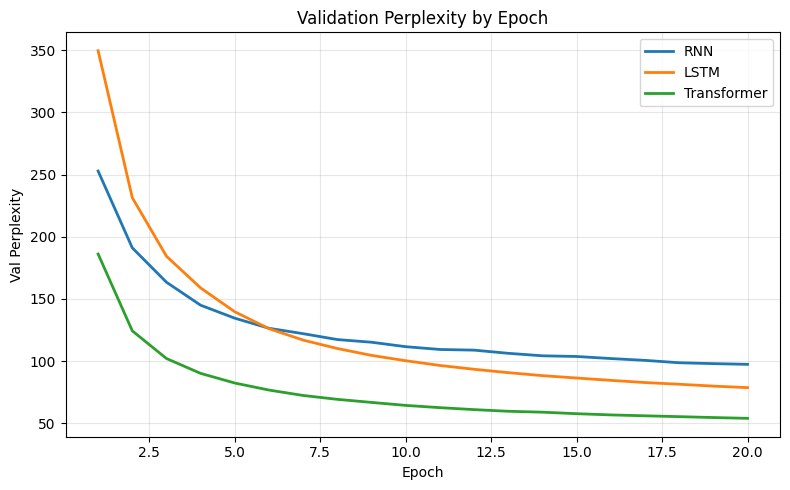

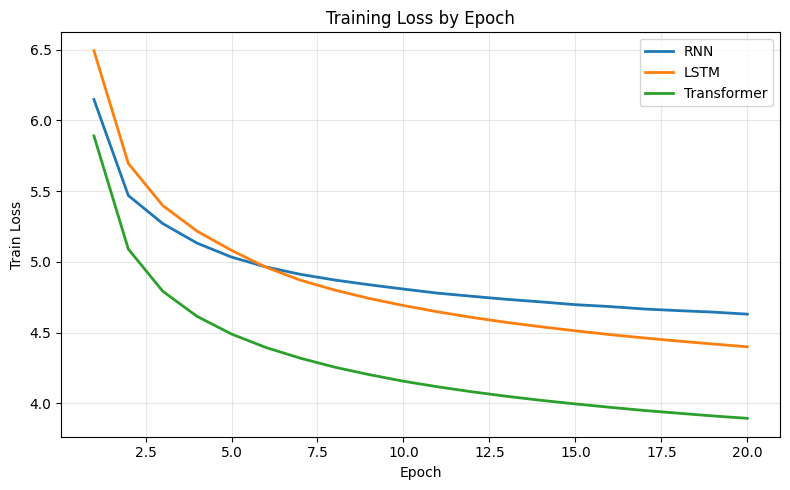

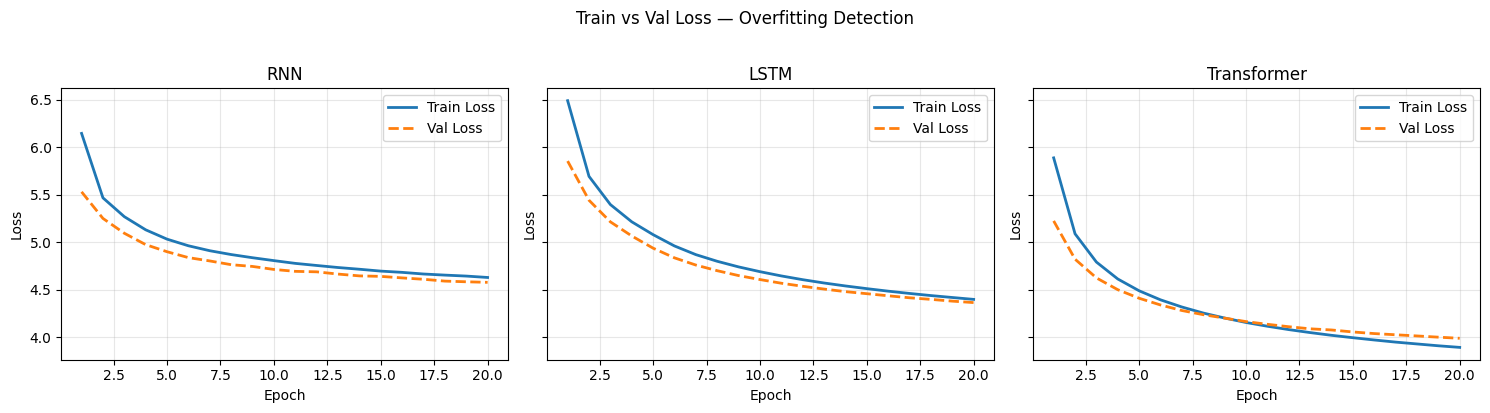

In [11]:
# Validation perplexity curves
plot_training_curves(
    {
        'RNN': rnn_history['val_perplexity'],
        'LSTM': lstm_history['val_perplexity'],
        'Transformer': tf_history['val_perplexity'],
    },
    metric='val_perplexity',
    title='Validation Perplexity by Epoch',
    save_path='../outputs/plots/part1_val_perplexity.png',
)

# Training loss curves (detect overfitting by comparing train vs val)
plot_training_curves(
    {
        'RNN': rnn_history['train_loss'],
        'LSTM': lstm_history['train_loss'],
        'Transformer': tf_history['train_loss'],
    },
    metric='train_loss',
    title='Training Loss by Epoch',
    save_path='../outputs/plots/part1_train_loss.png',
)

# Train loss vs val loss overlay for overfitting detection
import matplotlib.pyplot as plt
from src.utils import MODEL_COLORS

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, history) in zip(axes, [
    ('RNN', rnn_history), ('LSTM', lstm_history), ('Transformer', tf_history)
]):
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], label='Train Loss', linestyle='-', linewidth=2)
    ax.plot(epochs, history['val_loss'], label='Val Loss', linestyle='--', linewidth=2)
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Train vs Val Loss — Overfitting Detection', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/plots/part1_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Qualitative: Text Generation Samples

In [10]:
from src.tokenizer import tokenize, SOS_IDX

prompts = config['generation']['prompts']
temperature = config['generation']['temperature']
max_gen_len = config['generation']['max_len']

print('=== N-gram Samples ===')
for name in ['2gram', '3gram']:
    print(f'\n--- {name} ---')
    for prompt in prompts:
        text = ngram_results[name]['model'].generate(prompt, max_len=max_gen_len)
        print(f'  [{prompt}] -> {text}')

print('\n=== Neural Model Samples ===')
for name, model in [('RNN', rnn_model), ('LSTM', lstm_model), ('Transformer', transformer_model)]:
    print(f'\n--- {name} ---')
    for prompt in prompts:
        prompt_tokens = tokenize(prompt)
        prompt_ids = [SOS_IDX] + [vocab.token2idx.get(t, 1) for t in prompt_tokens]
        text = generate_text(model, prompt_ids, vocab, device,
                           max_len=max_gen_len, temperature=temperature)
        print(f'  [{prompt}] -> {text}')

=== N-gram Samples ===

--- 2gram ---
  [the president of] -> the president of its bid more technical compliance measures to seven project at brewer and the wreckage of jobs its closely watched as tropical storm passed on tuesday night. s say dalai lama arrives in 2005 contract extension with something more of the world
  [scientists have discovered] -> scientists have discovered description: dph.
  [the stock market] -> the stock market for their convenience market fundamentals were forced to a gang quot; a big share their emphatic election inspired by oct. cloud
  [the team won] -> the team won nine afghan ethnic loyalties lay red tape appeared a coach dennis kozlowski: / / www. issued a # 39;

--- 3gram ---
  [the president of] -> the president of haiti # 39; technology stocks, after attackers blew up an independent inquiry into school siege remain in office before 2008, according to a study published by the russian president vladimir putin said friday its latest innovation, the sul

c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\torch\nn\functional.py:5109: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(


  [scientists have discovered] -> scientists have discovered about aborigines of religion the elephants of people found out in near even as scientists report scientists have discovered the insects known as animal attacks and traffic leaves to the origins of hurricane ivan and scientists say.
  [the stock market] -> the stock market, shares fall new york ( reuters ) - philippine shares blew up 16 percent on tuesday as losses receded on \ $ 94. 7 billion in overseas capital inflows and businesses that fell to a nine - year - old broker aircraft, a financial officer said.
  [the team won] -> the team won ' t play title winning season the first time for the english championship in the kansas city chiefs 16 minutes when jon gruden begin a 1 - 1 win over the reeling manchester united states in a semifinal round of the bronze games.


## 9. Analysis

**N-gram vs Neural Models:**
N-gram models show substantially higher perplexity (bigram 850, trigram 3736) compared to neural models (54–96). With Laplace smoothing, unseen n-grams spread probability mass across the entire 20K vocabulary, and each history is treated independently with no parameter sharing. The trigram is worse than the bigram because the much larger history space (1M distinct trigram histories vs 60K bigram) makes sparsity far more severe under add-one smoothing.

**RNN vs LSTM:**
LSTM (test PPL 77.8) outperforms RNN (96.3) despite comparable parameter counts (4.18M vs 4.06M). The LSTM's gating mechanism provides a gradient highway through the cell state, addressing the vanishing gradient problem and enabling better modeling of longer-range dependencies within the 128-token window.

**Transformer vs LSTM:**
The Transformer achieves the lowest perplexity (test PPL 53.6) by a wide margin. Self-attention creates direct connections between any two positions, avoiding the sequential information bottleneck of recurrent models. However, this comes at a cost: the Transformer is the slowest model both in training (~105s/epoch vs LSTM ~100s, RNN ~94s) and inference (2.26 ms/batch vs ~0.9 ms). At this small scale (seq_len=128, 2-layer, 100-dim), the O(n²) attention overhead is not offset by parallelism gains.

**Generated Text Quality:**
N-gram outputs show local coherence but quickly lose topic consistency due to the limited context window. Neural models maintain topic better — the RNN tends to drift after ~15 tokens, the LSTM holds slightly longer, and the Transformer produces the most coherent sequences (e.g., maintaining "Iraqi president" as a coherent topic throughout).

*All perplexity values are computed on sequences truncated to max_seq_len=128 across both n-gram and neural models for fair comparison. All neural models share the same 20K-word vocabulary and comparable parameter budgets (~4.1–4.3M).*